## Deep Learning

### Chapter 12: Image Segmentation with advanced Neural Network architectures

Image segmentation is a computer vision task that involves partitioning an image into multiple segments or regions, often to identify and classify objects within the image. In this chapter, we will explore how to build an encoder-decoder model for image segmentation using deep learning techniques.

1. Use Encoder-decoder model

Encoder-decoder architectures are commonly used for tasks that require generating output from input data, such as image segmentation. The encoder compresses the input image into a lower-dimensional representation, while the decoder reconstructs the segmented output from this representation.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# the seed() function is used to set the seed for generating random numbers. 
# This ensures that the results are reproducible, meaning that you 
# will get the same output each time you run the code with the same seed value.
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# This object is used to control the verbosity of TensorFlow's logging.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# These lines set the default figure size for plots to 10 inches by 4 inches and disable the grid on the axes.
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

Step 1 - Generate synthetic data

To train our encoder-decoder model, we will first generate synthetic data. This will allow us to create a controlled environment for testing our model's performance.

In [2]:
IMAGE_SIZE = 96
NUM_CLASSES = 3
CLASS_NAMES = ["background", "circle", "rectangle"]

# Each class is assigned a specific RGB color for visualization purposes. 
# The colors are defined in the MASK_COLORS array, where each row corresponds to a class ID 
# (0 for background, 1 for circle, and 2 for rectangle) and contains the RGB values for that class.

MASK_COLORS = np.array(
    [
        [20, 20, 40],      # background: dark blue
        [255, 210, 70],    # circle: yellow orange
        [80, 200, 255],    # rectangle: light blue
    ],
    dtype="uint8",
)


def make_synthetic_scene(image_size=IMAGE_SIZE, seed=None):
    # Create a synthetic scene with random shapes and corresponding masks.
    rng = np.random.default_rng(seed)

    image = np.ones((image_size, image_size, 3), dtype="float32") * 30
    image += rng.normal(loc=0, scale=4, size=image.shape)

    mask = np.zeros((image_size, image_size), dtype="uint8")

    yy, xx = np.mgrid[:image_size, :image_size]
    boxes = []

    # Label 1 is assigned to circles, and label 2 is assigned to rectangles in the mask.
    radius = int(rng.integers(image_size // 10, image_size // 6))
    cx = int(rng.integers(radius + 4, image_size - radius - 4))
    cy = int(rng.integers(radius + 4, image_size - radius - 4))
    circle_region = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    image[circle_region] = np.array([255, 210, 70])
    mask[circle_region] = 1
    boxes.append(("circle", cx - radius, cy - radius, cx + radius, cy + radius))

    rect_w = int(rng.integers(image_size // 5, image_size // 3))
    rect_h = int(rng.integers(image_size // 6, image_size // 3))
    x1 = int(rng.integers(4, image_size - rect_w - 4))
    y1 = int(rng.integers(4, image_size - rect_h - 4))
    x2 = x1 + rect_w
    y2 = y1 + rect_h
    image[y1:y2, x1:x2] = np.array([80, 200, 255])
    mask[y1:y2, x1:x2] = 2
    boxes.append(("rectangle", x1, y1, x2, y2))

    # Convert the image to uint8 format and ensure that pixel values are in the range [0, 255].
    image = np.clip(image, 0, 255).astype("uint8")
    return image, mask, boxes


def colorize_mask(mask):
    # Convert class IDs in the mask to RGB colors for visualization.
    # Use MASK_COLORS to map each class ID to an RGB color.
    return MASK_COLORS[mask]

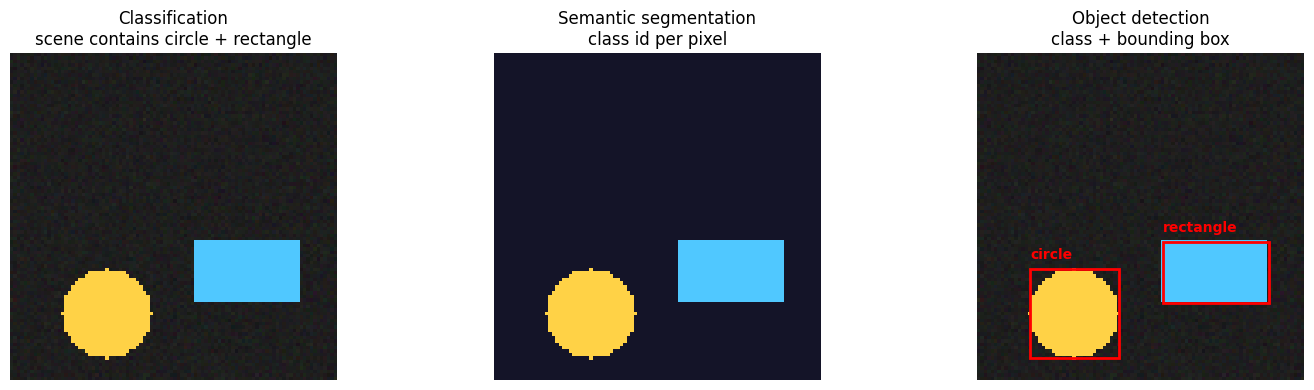

In [3]:
# Sample image generation with  make_synthetic_scene(seed=10).
image, mask, boxes = make_synthetic_scene(seed=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classification: Only need class labels for the whole image.
axes[0].imshow(image)
axes[0].set_title("Classification\nscene contains circle + rectangle")
axes[0].axis("off")

# Semantic segmentation: Require class id for each pixel
axes[1].imshow(colorize_mask(mask))
axes[1].set_title("Semantic segmentation\nclass id per pixel")
axes[1].axis("off")

# Object detection: Require bounding box
axes[2].imshow(image)
for class_name, x1, y1, x2, y2 in boxes:
    # Create Rectangle patch from bounding box.
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                             linewidth=2, edgecolor="red", facecolor="none")
    axes[2].add_patch(rect)
    axes[2].text(x1, y1 - 3, class_name, color="red", fontsize=10, weight="bold")
    
axes[2].set_title("Object detection\nclass + bounding box")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
def build_arrays(num_samples, seed_offset=0):
    """Generate images and masks to put into tf.data.Dataset."""
    images = []
    masks = []

    # Iterate through num_samples to generate image and mask
    for i in range(num_samples):
        image, mask, _ = make_synthetic_scene(seed=seed_offset + i)
        images.append(image)
        masks.append(mask[..., np.newaxis])

    images = np.array(images, dtype="uint8")
    masks = np.array(masks, dtype="uint8")
    return images, masks


TRAIN_SAMPLES = 240
VAL_SAMPLES = 60
BATCH_SIZE = 16

# Generate train_images/train_masks and val_images/val_masks.
train_images, train_masks = build_arrays(TRAIN_SAMPLES, seed_offset=0)
val_images, val_masks = build_arrays(VAL_SAMPLES, seed_offset=10_000)

# Generate train_ds from_tensor_slices, shuffle, batch, prefetch.
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_ds = train_ds.shuffle(512, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Generate val_ds by from_tensor_slices, batch, prefetch.
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train images:", train_images.shape)
print("Train masks:", train_masks.shape)

Train images: (240, 96, 96, 3)
Train masks: (240, 96, 96, 1)


Step 2 - Segmentation Encoder-Decoder Model

Next, we will define our encoder-decoder model architecture. The encoder will consist of convolutional layers that extract features from the input image, while the decoder will use transposed convolutional layers to upsample the feature maps and produce the segmented output.

In [5]:
def build_segmentation_model(image_size=IMAGE_SIZE, num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(image_size, image_size, 3), name="input_image")

    # Rescale pixel from [0, 255] to [0, 1].
    x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)

    # Encoder compresses 96 -> 48 -> 24 -> 12.
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu", name="encoder_conv_1")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu", name="encoder_conv_2")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu", name="encoder_conv_3")(x)

    # Decode reconstructs 12 -> 24 -> 48 -> 96.
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_1")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_2")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_3")(x)

    # The last layer predicts num_classes for each pixel.
    outputs = layers.Conv2D(num_classes, 3, padding="same", activation="softmax", name="pixel_classifier")(x)
    return keras.Model(inputs, outputs, name="toy_segmentation_model")


seg_model = build_segmentation_model()

seg_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],)

seg_model.summary()

Model: "toy_segmentation_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_1                │ (None, 24, 24, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_2                │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_3                │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_classifier (Conv2D)       │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 4

# EarlyStopping is used to stop training if the validation loss stops improving
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, 
                                           restore_best_weights=True,)]

# Train the model with train_ds and val_ds.
history = seg_model.fit(train_ds, validation_data=val_ds, 
                        epochs=EPOCHS, callbacks=callbacks,)

Epoch 1/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8747 - loss: 0.9383 - val_accuracy: 0.8891 - val_loss: 0.7220
Epoch 2/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8914 - loss: 0.4282 - val_accuracy: 0.8891 - val_loss: 0.1926
Epoch 3/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8914 - loss: 0.1611 - val_accuracy: 0.8891 - val_loss: 0.1497
Epoch 4/4
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9221 - loss: 0.1361 - val_accuracy: 0.9443 - val_loss: 0.1187


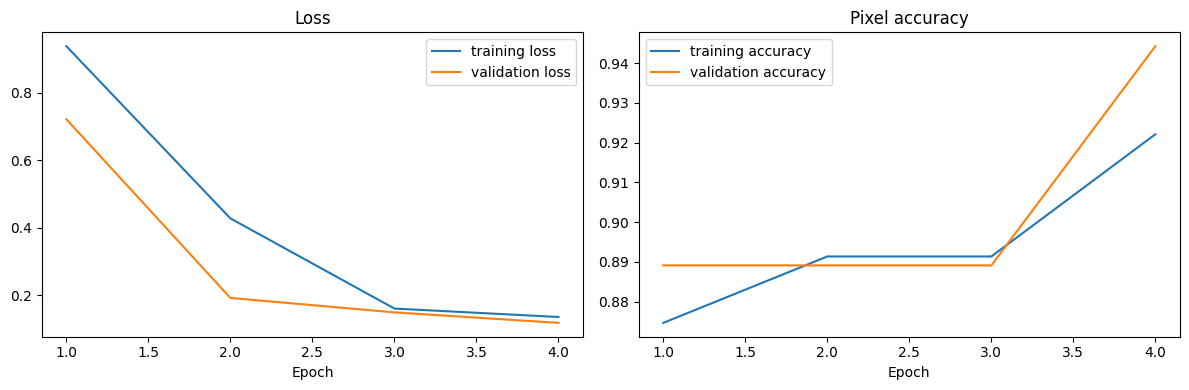

In [ ]:
def plot_training_history(history):
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, metrics["loss"], label="training loss")
    axes[0].plot(epochs, metrics["val_loss"], label="validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, metrics["accuracy"], label="training accuracy")
    axes[1].plot(epochs, metrics["val_accuracy"], label="validation accuracy")
    axes[1].set_title("Pixel accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


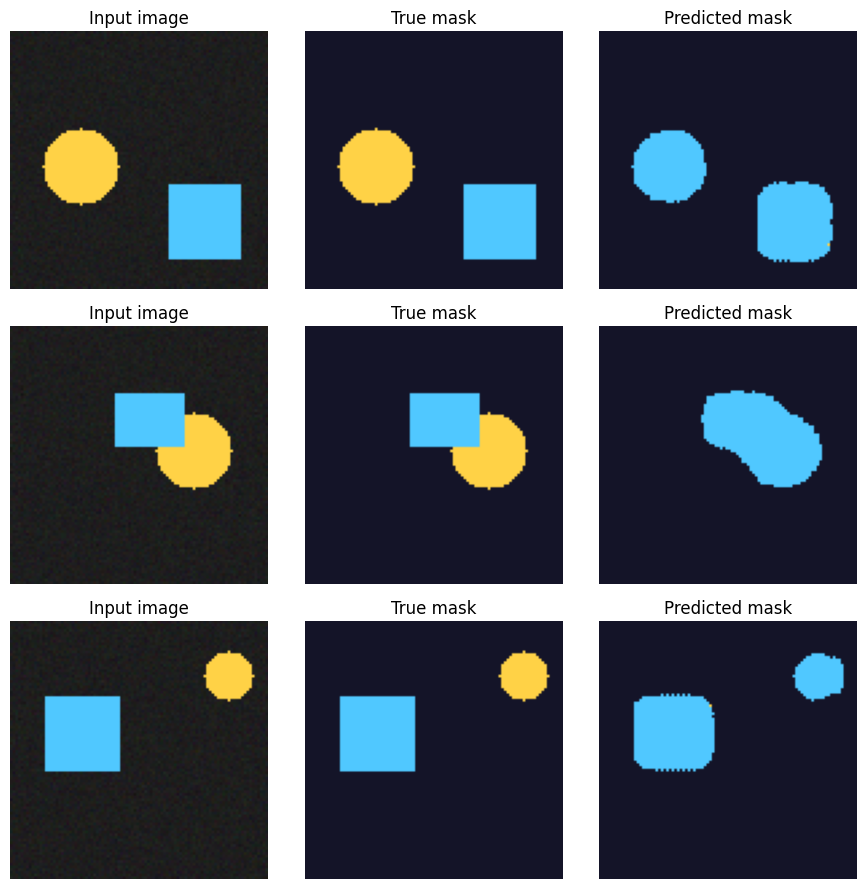

In [ ]:
# Use a batch validation to see how the model predict mask
sample_images, sample_masks = next(iter(val_ds))

# Prediction for the first three samples
pred_probs = seg_model.predict(sample_images[:3])

# Use argmax in class to get predicted
pred_masks = np.argmax(pred_probs, axis=-1).astype("uint8")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    axes[i, 0].imshow(sample_images[i].numpy().astype("uint8"))
    axes[i, 0].set_title("Input image")
    axes[i, 0].axis("off")

    true_mask = sample_masks[i].numpy().squeeze()
    axes[i, 1].imshow(colorize_mask(true_mask))
    axes[i, 1].set_title("True mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(colorize_mask(pred_masks[i]))
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

2. Use advanced CNN model

In [12]:
# Helper function to calculate the number of trainable parameters
# for any convolutional layer. A temporary model is created so
# Keras can automatically compute the parameter count.
def count_params_for_layer(layer):
    inputs = keras.Input(shape=(32, 32, 64))
    model = keras.Model(inputs, layer(inputs))
    return model.count_params()

# Create a standard Conv2D layer and count its parameters.
standard_params = count_params_for_layer(
    layers.Conv2D(64, 3, padding="same", use_bias=False))

# Create a SeparableConv2D layer and count its parameters.
# Separable convolutions split spatial filtering and channel mixing,
# resulting in significantly fewer parameters.
separable_params = count_params_for_layer(
    layers.SeparableConv2D(64, 3, padding="same", use_bias=False))

# Display the parameter counts and the reduction factor.
print("Standard Conv2D parameters:", standard_params)
print("SeparableConv2D parameters:", separable_params)
print("Parameter reduction:", round(standard_params / separable_params, 2), "times")

Standard Conv2D parameters: 36864
SeparableConv2D parameters: 4672
Parameter reduction: 7.89 times


In [13]:
# Residual block used in ResNet architectures.
# The shortcut connection allows information and gradients
# to flow directly through the network, helping train deeper models.
def residual_block(x, filters, stride=1, name="residual_block"):
    residual = x

    # First convolution + batch normalization + ReLU activation
    x = layers.Conv2D(filters, 3, strides=stride, padding="same",
                      use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    # Second convolution + batch normalization
    x = layers.Conv2D(filters, 3, padding="same",
                      use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # Use a projection shortcut when the tensor shape changes
    # (e.g., different number of filters or downsampling).
    if residual.shape[-1] != filters or stride != 1:
        residual = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                 use_bias=False, name=f"{name}_projection")(residual)

    # Add the shortcut connection and apply the final activation.
    x = layers.add([x, residual], name=f"{name}_add")
    return layers.Activation("relu", name=f"{name}_out")(x)

In [14]:
# Simple CNN with two residual blocks for image classification.
inputs = keras.Input(shape=(64, 64, 3), name="input")

# Input preprocessing and stem layer.
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 3, padding="same",
                  use_bias=False, name="stem_conv")(x)
x = layers.BatchNormalization(name="stem_bn")(x)
x = layers.Activation("relu", name="stem_relu")(x)

# Residual blocks.
x = residual_block(x, 32, stride=1, name="block1")
x = residual_block(x, 64, stride=2, name="block2")

# Classification head.
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
outputs = layers.Dense(3, activation="softmax", name="classifier")(x)

residual_demo_model = keras.Model(inputs, outputs, 
                                  name="residual_demo_model")

residual_demo_model.summary()

Model: "residual_demo_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 64, 64,    │      9,216 │ stem_relu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 64, 64,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 64, 64,    │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 64, 64,    │      9,216 │ block1_relu1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 64, 64,    │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 64, 64,    │          0 │ block1_bn2[0][0], │
│                     │ 32)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out          │ (None, 64, 64,    │          0 │ block1_add[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 32, 32,    │     18,432 │ block1_out[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 32, 32,    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1        │ (None, 32, 32,    │          0 │ block2_bn1[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 32, 32,    │     36,864 │ block2_relu1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 32, 32,    │        256 │ block2_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 77,731 (303.64 KB)

 Trainable params: 77,283 (301.89 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Mini Xception block using depthwise separable convolutions.
# A projection shortcut is used to match dimensions after downsampling.
def xception_like_block(x, filters, stride=2, name="xception_like_block"):
    residual = x

    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same",
                               use_bias=False, name=f"{name}_sepconv1")(x)

    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same",
                               use_bias=False, name=f"{name}_sepconv2")(x)

    x = layers.MaxPooling2D(3, strides=stride,
                            padding="same", name=f"{name}_pool")(x)

    residual = layers.Conv2D(filters, 1, strides=stride,
                             padding="same", use_bias=False,
                             name=f"{name}_projection")(residual)

    return layers.add([x, residual], name=f"{name}_add")

In [16]:
# Mini Xception-style classifier using separable convolution blocks.
inputs = keras.Input(shape=(96, 96, 3), name="input")

# Input preprocessing and entry layer.
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 5, padding="same",
                  use_bias=False, name="entry_conv")(x)

# Xception feature extraction blocks.
for filters in [32, 64, 128]:
    x = xception_like_block(x, filters,
                            name=f"xception_block_{filters}")

# Classification head.
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(2, activation="softmax",
                       name="classifier")(x)

xception_demo_model = keras.Model(inputs, 
                                  outputs, name="mini_xception_like_model")

xception_demo_model.summary()

Model: "mini_xception_like_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 96, 96, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv (Conv2D) │ (None, 96, 96,    │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ entry_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │      1,024 │ entry_conv[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (Add)               │ 32)               │            │ xception_block_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │      2,336 │ xception_block_6… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        256 │ xception_block_6… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 64)               │            │                 

 Total params: 51,266 (200.26 KB)

 Trainable params: 50,562 (197.51 KB)

 Non-trainable params: 704 (2.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


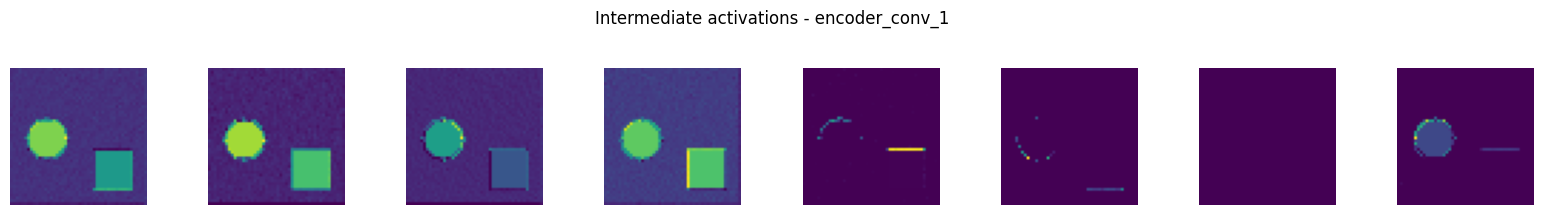

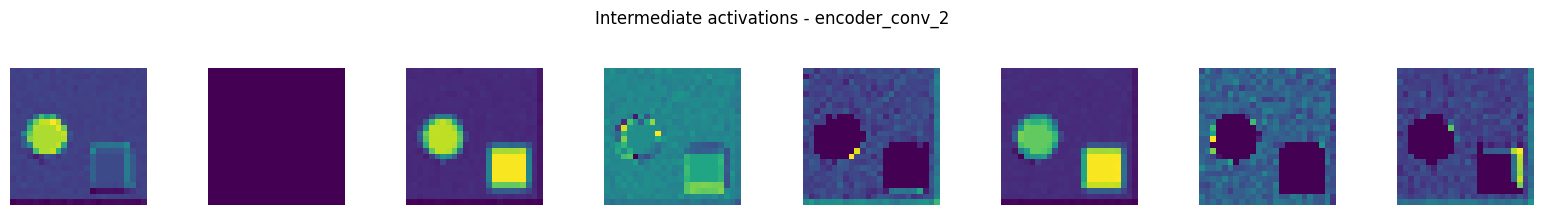

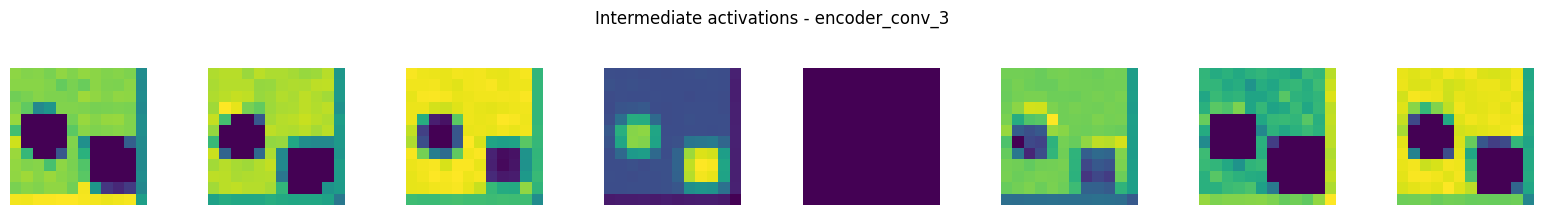

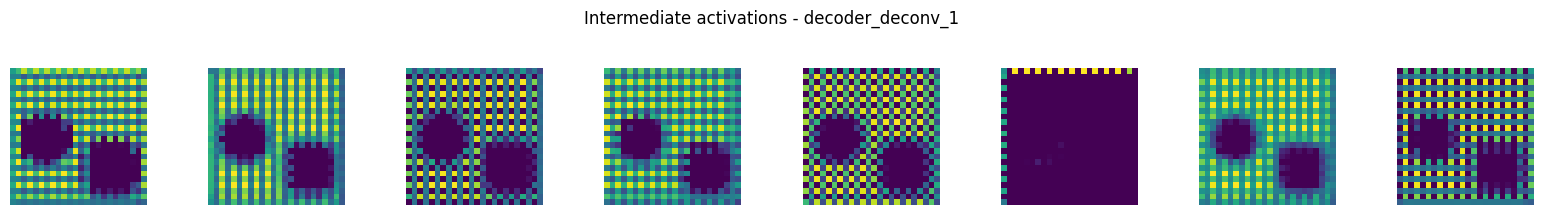

In [19]:
# Intermediate Activations
test_image = sample_images[:1]

layer_names = ["encoder_conv_1", "encoder_conv_2", 
               "encoder_conv_3", "decoder_deconv_1"]

layer_outputs = [seg_model.get_layer(name).output
                 for name in layer_names]

activation_model = keras.Model(seg_model.input, layer_outputs)
activations = activation_model.predict(test_image)

for layer_name, activation in zip(layer_names, activations):
    num_channels = min(8, activation.shape[-1])
    fig, axes = plt.subplots(1, num_channels, figsize=(2 * num_channels, 2))
    fig.suptitle(f"Intermediate activations - {layer_name}", y=1.05)

    for channel_index in range(num_channels):
        # Take a 2D feature map 2D and normalize
        channel_image = activation[0, :, :, channel_index]

        channel_image = channel_image - channel_image.mean()
        channel_image = channel_image / (channel_image.std() + 1e-6)

        axes[channel_index].imshow(channel_image, cmap="viridis")
        axes[channel_index].axis("off")

    plt.tight_layout()
    plt.show()

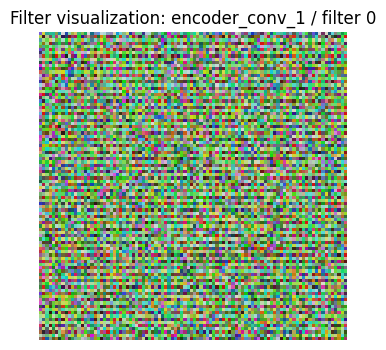

In [18]:
def deprocess_image(x):
    x = x - x.mean()
    x = x / (x.std() + 1e-6)
    x = x * 64 + 128
    x = np.clip(x, 0, 255).astype("uint8")
    return x


def generate_filter_pattern(model, layer_name, filter_index=0, steps=40, learning_rate=10.0):
    # Input image as filter, strongly activated with gradient ascent
    # Create feature_extractor to return activation of target layer
    feature_extractor = keras.Model(model.input, model.get_layer(layer_name).output)

    # Random image within [0, 255].
    image = tf.Variable(tf.random.uniform((1, IMAGE_SIZE, IMAGE_SIZE, 3), minval=0, maxval=255))

    for step in range(steps):
        with tf.GradientTape() as tape:
            activation = feature_extractor(image)
            loss = tf.reduce_mean(activation[:, :, :, filter_index])

        # Compute and normalize gradient, upddate image theo gradient ascent.
        grads = tape.gradient(loss, image)
        grads = grads / (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-6)
        image.assign_add(learning_rate * grads)
        image.assign(tf.clip_by_value(image, 0, 255))

    return deprocess_image(image.numpy()[0])


pattern = generate_filter_pattern(seg_model, layer_name="encoder_conv_1", filter_index=0)

plt.figure(figsize=(4, 4))
plt.imshow(pattern)
plt.title("Filter visualization: encoder_conv_1 / filter 0")
plt.axis("off")
plt.show()